# Phần 2 — Notebook Analytics Vòng 1

Notebook này là bản **analytics / business analysis** chuẩn cho Part 2.
Report chỉ lấy một phần trong các section bên dưới, nhưng mọi insight Part 2 giữ lại trong report đều phải có nguồn ở notebook này.

Notebook được thiết kế để kéo điểm **Phần 2 — Trực quan hoá & Phân tích Dữ liệu** theo đúng rubric vòng 1:

- **Mô tả**: mô tả đúng mẫu hình và quy mô ảnh hưởng
- **Chẩn đoán**: giải thích nguyên nhân khả dĩ
- **Dự báo**: chỉ ra tính mùa vụ và các chỉ báo sớm
- **Khuyến nghị**: chốt thành hành động có KPI và mức độ ưu tiên

Storyline chính của notebook:

1. Nhu cầu bước vào trạng thái mới từ 2019 nhưng mùa vụ vẫn rất rõ
2. Doanh thu đi cùng **số đơn** và **chuyển đổi** nhiều hơn lưu lượng truy cập thô
3. Khuyến mãi có tác dụng, nhưng một số cơ chế đang phá biên lợi nhuận
4. COD, wrong-size và phân bổ tồn kho là các điểm rò rỉ hiệu quả lớn nhất
5. Tập khách quay lại vẫn lớn, nhưng cohort mới giữ chân yếu hơn rõ rệt
6. Margin theo danh mục và chất lượng kênh giúp chốt ưu tiên ngân sách cuối cùng


In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

warnings.filterwarnings("ignore")

plt.rcParams.update(
    {
        "figure.figsize": (12, 5),
        "figure.dpi": 130,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
    }
)

def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "dataset").exists() and (candidate / "report").exists():
            return candidate
    raise FileNotFoundError("Không tìm thấy repo root chứa dataset/ và report/.")

ROOT = find_repo_root(Path.cwd())
DATA = ROOT / "dataset"

sales = pd.read_csv(DATA / "sales.csv", parse_dates=["Date"])
orders = pd.read_csv(DATA / "orders.csv", parse_dates=["order_date"])
order_items = pd.read_csv(DATA / "order_items.csv", low_memory=False)
products = pd.read_csv(DATA / "products.csv")
promotions = pd.read_csv(DATA / "promotions.csv", parse_dates=["start_date", "end_date"])
returns = pd.read_csv(DATA / "returns.csv", parse_dates=["return_date"])
geography = pd.read_csv(DATA / "geography.csv")
inventory = pd.read_csv(DATA / "inventory.csv", parse_dates=["snapshot_date"])
web = pd.read_csv(DATA / "web_traffic.csv", parse_dates=["date"])

def fmt_billion(x, _):
    return f"{x / 1e9:.1f}B"

def fmt_million(x, _):
    return f"{x / 1e6:.0f}M"

BILLION_FMT = FuncFormatter(fmt_billion)
MILLION_FMT = FuncFormatter(fmt_million)

print("Đã tải các bảng dữ liệu:")
print(
    {
        "sales": sales.shape,
        "orders": orders.shape,
        "order_items": order_items.shape,
        "products": products.shape,
        "promotions": promotions.shape,
        "returns": returns.shape,
        "inventory": inventory.shape,
        "web_traffic": web.shape,
    }
)


Đã tải các bảng dữ liệu:
{'sales': (3833, 3), 'orders': (646945, 8), 'order_items': (714669, 7), 'products': (2412, 8), 'promotions': (50, 10), 'returns': (39939, 7), 'inventory': (60247, 17), 'web_traffic': (3652, 7)}


## Tóm tắt điều hành

Bốn phát hiện chính mà notebook này muốn chứng minh:

- Doanh thu ngày trung bình giảm mạnh sau 2018, nhưng **hình dạng mùa vụ** vẫn ổn định và đủ mạnh để dùng cho lập kế hoạch.
- Doanh thu bám theo **số đơn** và **chuyển đổi** mạnh hơn hẳn so với lưu lượng truy cập thô, nên bài toán không chỉ là "đổ thêm lượt truy cập".
- Khuyến mãi kiểu `percentage` vẫn dùng được, nhưng khuyến mãi kiểu `fixed` đang tạo doanh thu với **lợi nhuận gộp âm**.
- Streetwear là động cơ doanh thu lớn nhất, nhưng cũng là điểm tập trung của hoàn tiền, trả hàng và lệch pha tồn kho.
- Tỷ lệ mua lại vẫn cao, nhưng retention của cohort mới yếu dần theo thời gian và cần chiến dịch re-engagement đúng lúc.


In [2]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_vi = {
    "Monday": "Thứ 2",
    "Tuesday": "Thứ 3",
    "Wednesday": "Thứ 4",
    "Thursday": "Thứ 5",
    "Friday": "Thứ 6",
    "Saturday": "Thứ 7",
    "Sunday": "Chủ nhật",
}
month_labels = ["T1", "T2", "T3", "T4", "T5", "T6", "T7", "T8", "T9", "T10", "T11", "T12"]

items = (
    order_items.merge(
        orders[
            [
                "order_id",
                "order_date",
                "payment_method",
                "order_source",
                "device_type",
                "order_status",
                "zip",
            ]
        ],
        on="order_id",
        how="left",
    )
    .merge(products[["product_id", "category", "segment", "size", "price", "cogs"]], on="product_id", how="left")
    .merge(promotions[["promo_id", "promo_type", "promo_channel"]], on="promo_id", how="left")
    .merge(geography[["zip", "region", "city"]], on="zip", how="left")
)
items["revenue"] = items["unit_price"] * items["quantity"]
items["gross_profit"] = items["revenue"] - items["cogs"] * items["quantity"]
items["discount_rate"] = items["discount_amount"] / (items["revenue"] + items["discount_amount"]).replace(0, np.nan)
items["promo_used"] = items["promo_id"].notna()
items["year"] = items["order_date"].dt.year
items["month"] = items["order_date"].dt.month

order_revenue = items.groupby("order_id")["revenue"].sum().rename("order_revenue")
order_gp = items.groupby("order_id")["gross_profit"].sum().rename("order_gp")
returned = returns.groupby("order_id").agg(
    return_lines=("return_id", "count"),
    refund_amount=("refund_amount", "sum"),
)
order_level = (
    orders.merge(order_revenue, left_on="order_id", right_index=True, how="left")
    .merge(order_gp, left_on="order_id", right_index=True, how="left")
    .merge(returned, left_on="order_id", right_index=True, how="left")
)
order_level[["order_revenue", "order_gp", "return_lines", "refund_amount"]] = order_level[
    ["order_revenue", "order_gp", "return_lines", "refund_amount"]
].fillna(0)
order_level["cancelled"] = order_level["order_status"].eq("cancelled")
order_level["returned"] = order_level["return_lines"].gt(0)

daily_web = (
    web.groupby("date")
    .agg(
        sessions=("sessions", "sum"),
        visitors=("unique_visitors", "sum"),
        page_views=("page_views", "sum"),
    )
    .reset_index()
)
daily_orders = orders.groupby("order_date").size().rename("orders").reset_index()
daily = (
    sales.merge(daily_web, left_on="Date", right_on="date", how="left")
    .merge(daily_orders, left_on="Date", right_on="order_date", how="left")
)
daily["orders"] = daily["orders"].fillna(0)
daily["conversion_proxy"] = daily["orders"] / daily["visitors"]
daily["aov"] = daily["Revenue"] / daily["orders"].replace(0, np.nan)
daily["year"] = daily["Date"].dt.year
daily["month"] = daily["Date"].dt.month

recent = sales.loc[sales["Date"] >= "2019-01-01"].copy()
recent["year"] = recent["Date"].dt.year
recent["month"] = recent["Date"].dt.month
recent["dow"] = pd.Categorical(recent["Date"].dt.day_name(), categories=weekday_order, ordered=True)

annual_avg = sales.assign(year=sales["Date"].dt.year).groupby("year")[["Revenue", "COGS"]].mean().reset_index()
monthly_recent = recent.groupby("month")[["Revenue", "COGS"]].mean().reindex(range(1, 13))
dow_recent = recent.groupby("dow")[["Revenue", "COGS"]].mean().reindex(weekday_order)

returns_enriched = returns.merge(products[["product_id", "category", "segment", "size"]], on="product_id", how="left")
return_reason = returns_enriched["return_reason"].value_counts(normalize=True).mul(100)
size_return_rate = (
    returns_enriched.groupby("size").size() / items.groupby("size").size()
).reindex(["S", "M", "L", "XL"]).mul(100)
category_return_rate = (
    returns_enriched.groupby("category").size() / items.groupby("category").size()
).sort_values(ascending=False).mul(100)

promo_summary = items.groupby("promo_used").agg(
    lines=("order_id", "size"),
    revenue=("revenue", "sum"),
    gross_profit=("gross_profit", "sum"),
    avg_discount_rate=("discount_rate", "mean"),
)
promo_summary["margin"] = promo_summary["gross_profit"] / promo_summary["revenue"]
promo_summary.index = promo_summary.index.map({False: "Không dùng khuyến mãi", True: "Có dùng khuyến mãi"})

promo_type = items.loc[items["promo_used"]].groupby("promo_type").agg(
    lines=("order_id", "size"),
    revenue=("revenue", "sum"),
    gross_profit=("gross_profit", "sum"),
    avg_discount_rate=("discount_rate", "mean"),
)
promo_type["margin"] = promo_type["gross_profit"] / promo_type["revenue"]

promo_channel = items.loc[items["promo_used"]].groupby("promo_channel").agg(
    lines=("order_id", "size"),
    revenue=("revenue", "sum"),
    gross_profit=("gross_profit", "sum"),
)
promo_channel["margin"] = promo_channel["gross_profit"] / promo_channel["revenue"]
promo_channel = promo_channel.sort_values("revenue", ascending=False)

payment_cancel = order_level.groupby("payment_method")["cancelled"].mean().mul(100).sort_values(ascending=False)

category_portfolio = items.groupby("category").agg(
    revenue=("revenue", "sum"),
    gross_profit=("gross_profit", "sum"),
    lines=("order_id", "size"),
)
category_portfolio["rev_share"] = category_portfolio["revenue"] / category_portfolio["revenue"].sum()
category_portfolio["margin"] = category_portfolio["gross_profit"] / category_portfolio["revenue"]
category_portfolio = category_portfolio.join(
    (
        returns_enriched.groupby("category").size()
        / items.groupby("category").size()
    ).rename("return_rate")
)
category_portfolio = category_portfolio.join(
    inventory.groupby("category")[["stockout_flag", "overstock_flag", "days_of_supply", "fill_rate"]].mean()
)
category_portfolio = category_portfolio.sort_values("revenue", ascending=False)

rates = order_level.groupby("payment_method")["cancelled"].mean()
cod_orders = order_level.loc[order_level["payment_method"] == "cod"]
cod_revenue_at_risk = max(rates.get("cod", 0) - rates.get("credit_card", 0), 0) * len(cod_orders) * cod_orders.loc[
    cod_orders["cancelled"], "order_revenue"
].mean()
fixed_gp_drag = abs(float(promo_type.loc["fixed", "gross_profit"])) if "fixed" in promo_type.index else np.nan
streetwear_wrong_size_refund = returns_enriched.loc[
    (returns_enriched["category"] == "Streetwear") & (returns_enriched["return_reason"] == "wrong_size"),
    "refund_amount",
].sum()

action_df = pd.DataFrame(
    [
        {
            "initiative": "Thiết kế lại hoặc dừng khuyến mãi giảm tiền cố định",
            "annual_value_vnd": fixed_gp_drag,
            "kpi": "Biên lợi nhuận gộp theo khuyến mãi",
            "why_now": "Khuyến mãi giảm thẳng tiền hiện đang cho lợi nhuận gộp âm.",
        },
        {
            "initiative": "Kéo tỷ lệ huỷ COD về gần mức thẻ",
            "annual_value_vnd": cod_revenue_at_risk,
            "kpi": "Tỷ lệ huỷ COD",
            "why_now": "COD đang có tỷ lệ huỷ gần gấp đôi nhóm thẻ.",
        },
        {
            "initiative": "Giảm 10% hoàn tiền do sai size của Streetwear",
            "annual_value_vnd": streetwear_wrong_size_refund * 0.10,
            "kpi": "Giá trị hoàn tiền do sai size",
            "why_now": "Streetwear tập trung cả quy mô lẫn nỗi đau về trả hàng.",
        },
    ]
).sort_values("annual_value_vnd", ascending=True)

print("Đã chuẩn bị xong các bảng phân tích.")


Đã chuẩn bị xong các bảng phân tích.


## 1. Nền cầu cơ bản: bước ngoặt cấu trúc và tính mùa vụ

Phần này trả lời ba câu hỏi:

- **Điều gì đã xảy ra?** Mức cầu thay đổi thế nào theo năm?
- **Nhu cầu đạt đỉnh khi nào?** Mùa nào và ngày nào trong tuần quan trọng nhất?
- **Nên làm gì?** Kế hoạch tồn kho, chiến dịch và nhân lực nên dồn vào đâu?


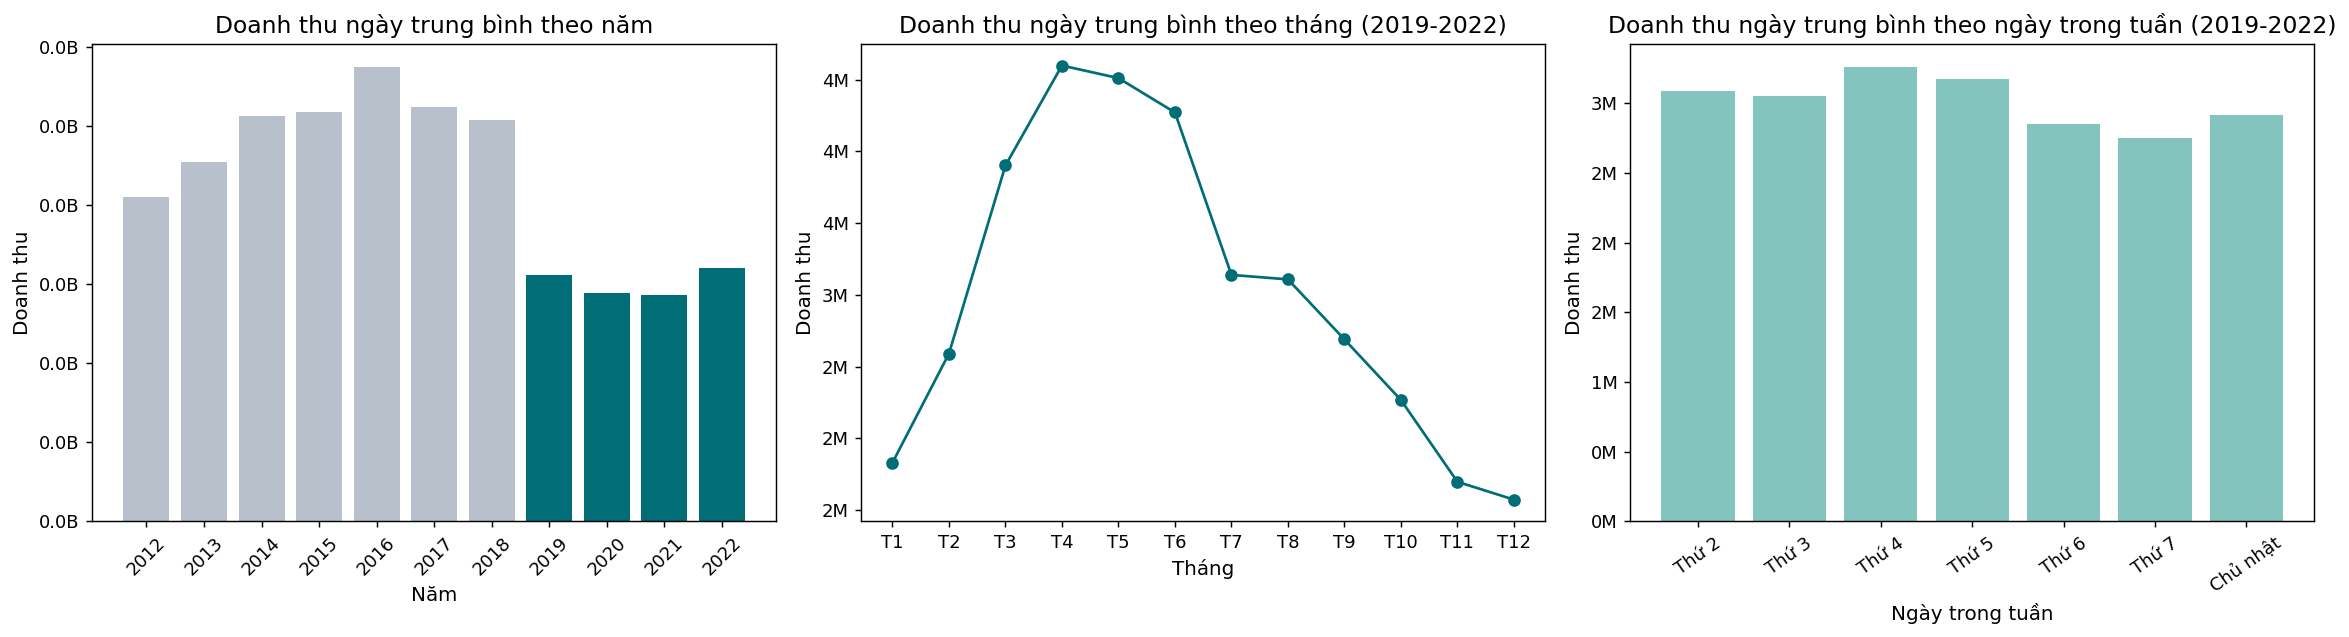

Doanh thu ngày trung bình giảm từ 5,070,141 xuống 3,014,444 VND sau năm 2018 (giảm 40.5%).
Tháng đỉnh = T4 với 4,598,619 VND/ngày; tháng thấp nhất = T12 với 1,572,274 VND/ngày.
Ngày mạnh nhất = Thứ 4 với 3,264,366 VND/ngày; ngày yếu nhất = Thứ 7 với 2,751,209 VND/ngày.


In [3]:
pre_2019_avg = sales.loc[sales["Date"] <= "2018-12-31", "Revenue"].mean()
post_2019_avg = sales.loc[sales["Date"] >= "2019-01-01", "Revenue"].mean()
drop_pct = (1 - post_2019_avg / pre_2019_avg) * 100

peak_month = int(monthly_recent["Revenue"].idxmax())
trough_month = int(monthly_recent["Revenue"].idxmin())
peak_dow = dow_recent["Revenue"].idxmax()
trough_dow = dow_recent["Revenue"].idxmin()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

year_colors = ["#b8c0cc" if y < 2019 else "#006d77" for y in annual_avg["year"]]
axes[0].bar(annual_avg["year"].astype(str), annual_avg["Revenue"], color=year_colors)
axes[0].set_title("Doanh thu ngày trung bình theo năm")
axes[0].set_xlabel("Năm")
axes[0].set_ylabel("Doanh thu")
axes[0].yaxis.set_major_formatter(BILLION_FMT)
axes[0].tick_params(axis="x", rotation=45)

axes[1].plot(month_labels, monthly_recent["Revenue"].values, marker="o", color="#006d77")
axes[1].set_title("Doanh thu ngày trung bình theo tháng (2019-2022)")
axes[1].set_xlabel("Tháng")
axes[1].set_ylabel("Doanh thu")
axes[1].yaxis.set_major_formatter(MILLION_FMT)

axes[2].bar([weekday_vi[d] for d in dow_recent.index.astype(str)], dow_recent["Revenue"].values, color="#83c5be")
axes[2].set_title("Doanh thu ngày trung bình theo ngày trong tuần (2019-2022)")
axes[2].set_xlabel("Ngày trong tuần")
axes[2].set_ylabel("Doanh thu")
axes[2].yaxis.set_major_formatter(MILLION_FMT)
axes[2].tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

print(f"Doanh thu ngày trung bình giảm từ {pre_2019_avg:,.0f} xuống {post_2019_avg:,.0f} VND sau năm 2018 (giảm {drop_pct:.1f}%).")
print(
    f"Tháng đỉnh = {month_labels[peak_month - 1]} với {monthly_recent.loc[peak_month, 'Revenue']:,.0f} VND/ngày; "
    f"tháng thấp nhất = {month_labels[trough_month - 1]} với {monthly_recent.loc[trough_month, 'Revenue']:,.0f} VND/ngày."
)
print(
    f"Ngày mạnh nhất = {weekday_vi[peak_dow]} với {dow_recent.loc[peak_dow, 'Revenue']:,.0f} VND/ngày; "
    f"ngày yếu nhất = {weekday_vi[trough_dow]} với {dow_recent.loc[trough_dow, 'Revenue']:,.0f} VND/ngày."
)


**Diễn giải**

- Đây không còn là một chuỗi "một trạng thái" xuyên suốt 2012-2022. Nếu huấn luyện mô hình hoặc lập kế hoạch mà đối xử toàn bộ lịch sử như nhau, bài toán sẽ bị lệch về mức doanh thu cũ.
- Mùa vụ vẫn rất rõ ngay cả sau khi mặt bằng doanh thu đã đổi. Điều này tạo nền tảng tốt cho cả lập kế hoạch và dự báo.

**Hàm ý kinh doanh**

- Nên ưu tiên hàng, ngân sách chiến dịch và năng lực giao vận cho cụm `Mar-Jun`.
- Không nên đánh giá hiệu quả tháng 11-12 theo cùng kỳ vọng mặt bằng với tháng 3-6.


## 2. Lượt truy cập không phải toàn bộ câu chuyện: số đơn và chuyển đổi mới là đòn bẩy gần doanh thu hơn

Phần này nhằm tránh một bẫy phổ biến trong phân tích thương mại điện tử: nhìn thấy lượt truy cập tăng rồi mặc định doanh thu sẽ tăng tương ứng.


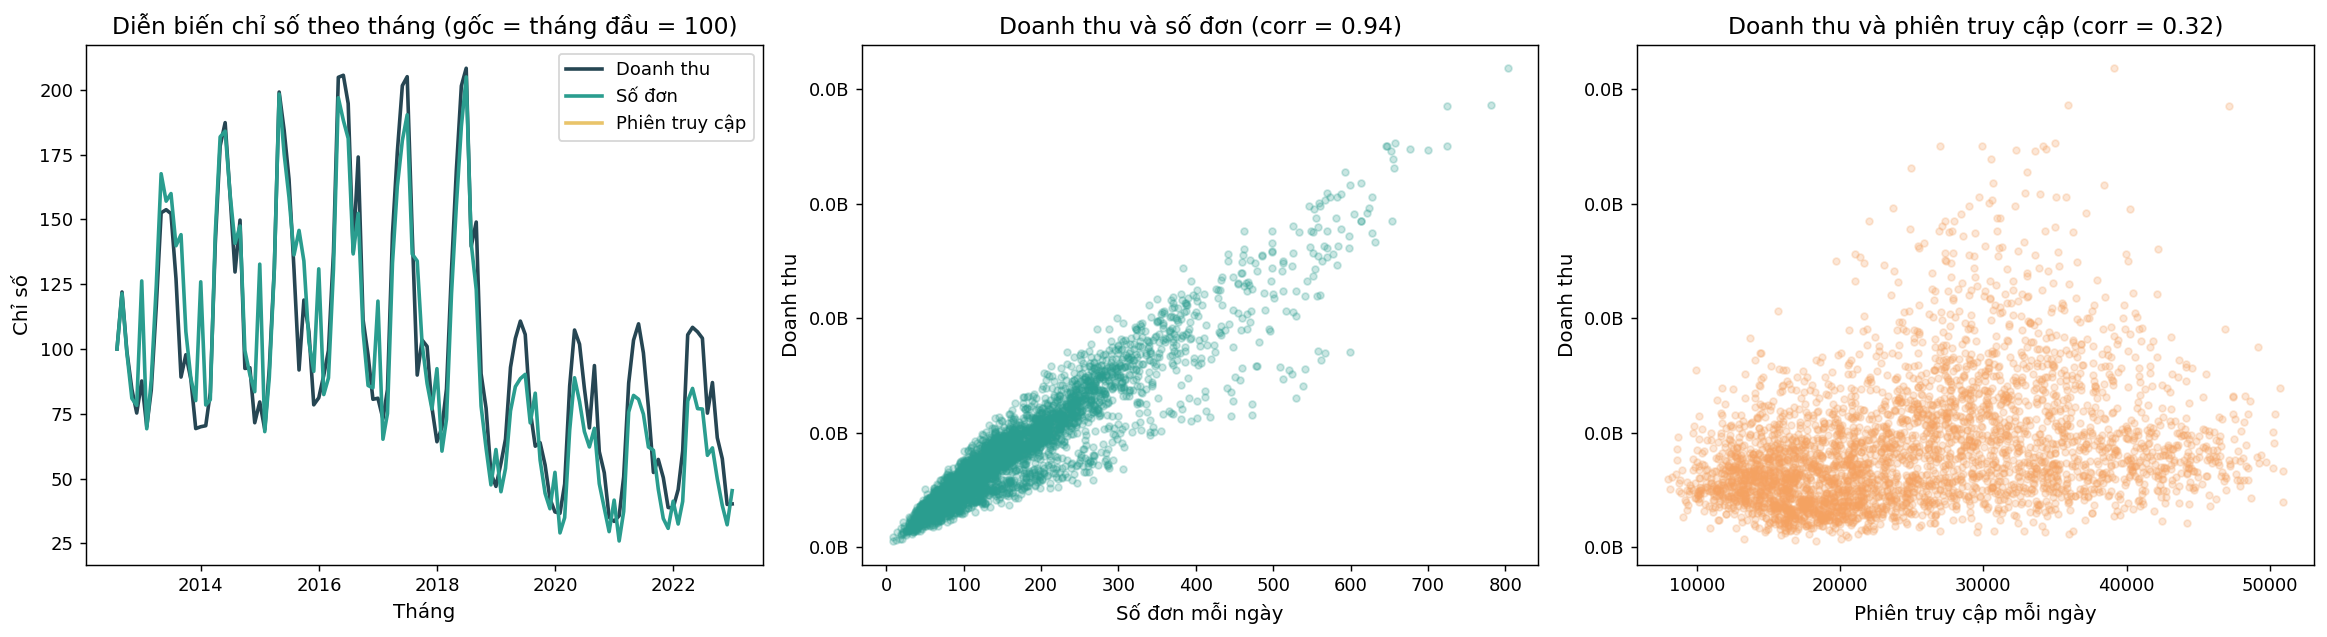

Tương quan với doanh thu
Revenue             1.0000
orders              0.9359
conversion_proxy    0.6259
sessions            0.3211
visitors            0.3188
aov                -0.0730


In [4]:
monthly_flow = daily.set_index("Date").resample("ME").sum(numeric_only=True)[["Revenue", "orders", "sessions"]]
indexed_flow = monthly_flow / monthly_flow.iloc[0] * 100

corr_table = daily[["Revenue", "orders", "sessions", "visitors", "conversion_proxy", "aov"]].corr()["Revenue"].sort_values(ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(indexed_flow.index, indexed_flow["Revenue"], label="Doanh thu", lw=2, color="#264653")
axes[0].plot(indexed_flow.index, indexed_flow["orders"], label="Số đơn", lw=2, color="#2a9d8f")
axes[0].plot(indexed_flow.index, indexed_flow["sessions"], label="Phiên truy cập", lw=2, color="#e9c46a")
axes[0].set_title("Diễn biến chỉ số theo tháng (gốc = tháng đầu = 100)")
axes[0].set_xlabel("Tháng")
axes[0].set_ylabel("Chỉ số")
axes[0].legend()

axes[1].scatter(daily["orders"], daily["Revenue"], alpha=0.25, s=14, color="#2a9d8f")
axes[1].set_title(f"Doanh thu và số đơn (corr = {corr_table['orders']:.2f})")
axes[1].set_xlabel("Số đơn mỗi ngày")
axes[1].set_ylabel("Doanh thu")
axes[1].yaxis.set_major_formatter(BILLION_FMT)

axes[2].scatter(daily["sessions"], daily["Revenue"], alpha=0.25, s=14, color="#f4a261")
axes[2].set_title(f"Doanh thu và phiên truy cập (corr = {corr_table['sessions']:.2f})")
axes[2].set_xlabel("Phiên truy cập mỗi ngày")
axes[2].set_ylabel("Doanh thu")
axes[2].yaxis.set_major_formatter(BILLION_FMT)

plt.tight_layout()
plt.show()

print("Tương quan với doanh thu")
print(corr_table.round(4).to_string())


**Diễn giải**

- Doanh thu đi cùng **số đơn** gần như trực tiếp, trong khi sessions thô yếu hơn nhiều.
- `conversion_proxy = orders / visitors` mang nhiều tín hiệu hơn lưu lượng truy cập thô, nghĩa là hiệu quả phễu chuyển đổi quan trọng hơn chuyện chỉ tăng đầu phễu.

**Hàm ý kinh doanh**

- Nếu ngân sách có hạn, ưu tiên tối ưu tỷ lệ chuyển đổi, chất lượng trang đích, cơ cấu sản phẩm và trưng bày hàng hóa trước khi mua thêm lượt truy cập.
- Trong bảng theo dõi vận hành, nên theo dõi `orders`, `conversion`, `AOV` cùng với sessions thay vì xem sessions một mình.


## 3. Kinh tế học khuyến mãi: có doanh thu kéo lên, nhưng biên lợi nhuận không phải lúc nào cũng đi cùng

Phần này chuyển phân tích từ "khuyến mãi có dùng nhiều không?" sang câu hỏi mà doanh nghiệp thực sự quan tâm:

- Khuyến mãi nào giữ được lợi nhuận gộp?
- Khuyến mãi nào chỉ tạo doanh thu bề mặt?


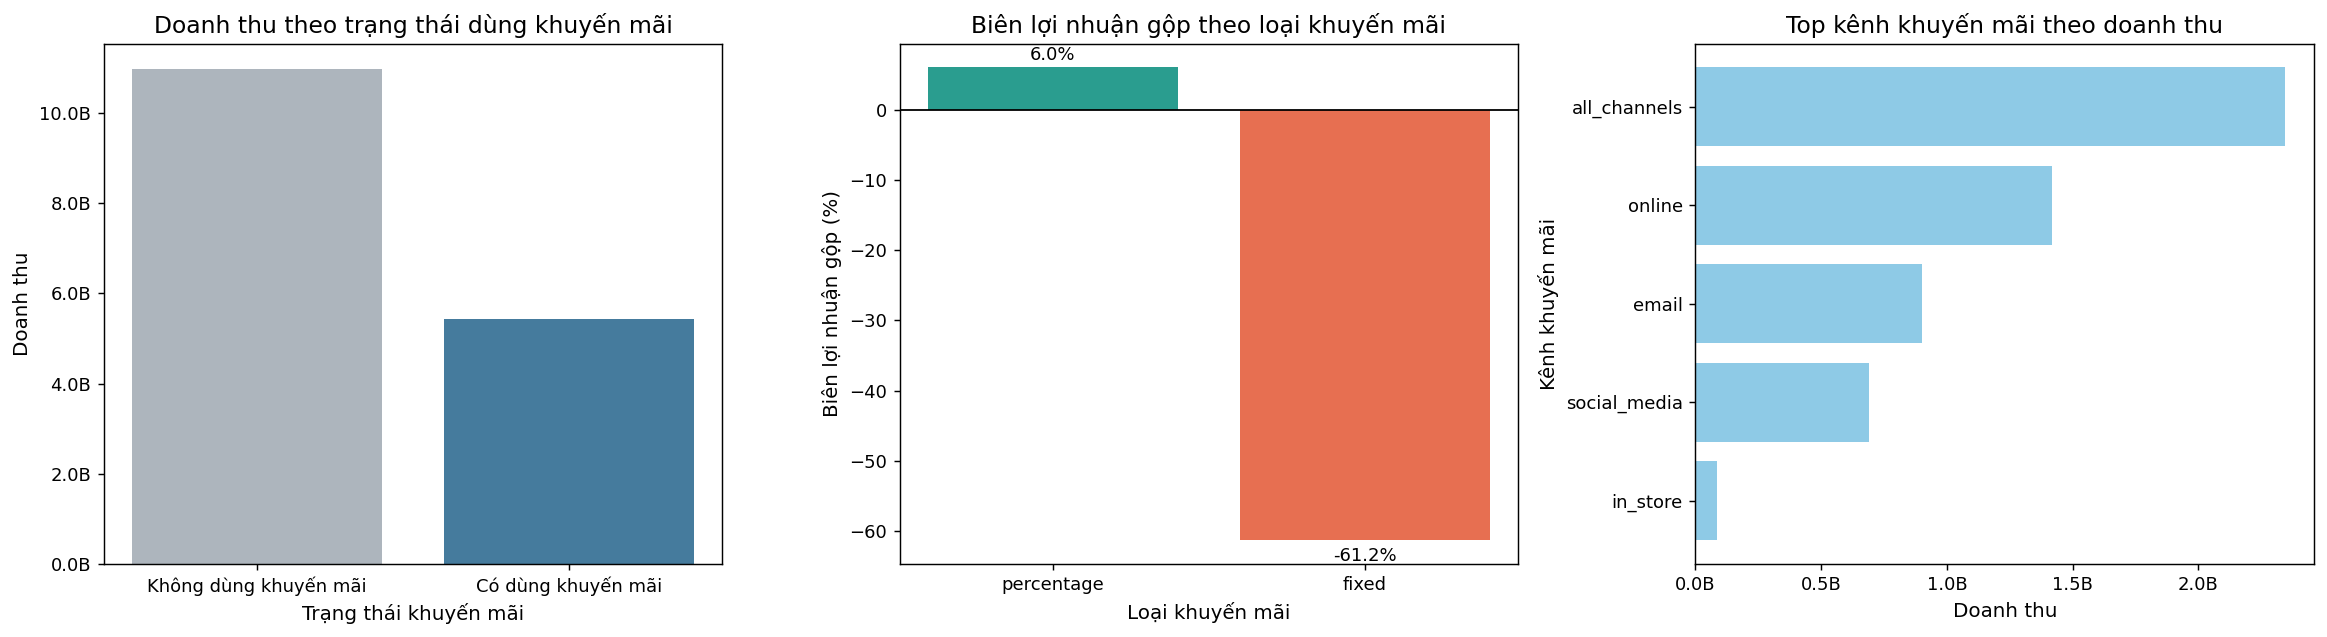

Tóm tắt theo trạng thái dùng khuyến mãi
                        lines       revenue  gross_profit  avg_discount_rate  margin
promo_used                                                                          
Không dùng khuyến mãi  438353  1.099504e+10  2.195015e+09               0.00   19.96
Có dùng khuyến mãi     276316  5.435438e+09  7.201068e+07              12.32    1.32

Tóm tắt theo loại khuyến mãi
             lines       revenue  gross_profit  avg_discount_rate  margin
promo_type                                                               
fixed        20950  3.764737e+08 -2.305307e+08               1.55  -61.23
percentage  255366  5.058964e+09  3.025414e+08              13.20    5.98


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(promo_summary.index, promo_summary["revenue"], color=["#adb5bd", "#457b9d"])
axes[0].set_title("Doanh thu theo trạng thái dùng khuyến mãi")
axes[0].set_xlabel("Trạng thái khuyến mãi")
axes[0].set_ylabel("Doanh thu")
axes[0].yaxis.set_major_formatter(BILLION_FMT)

promo_margin_pct = promo_type["margin"].mul(100).sort_values(ascending=False)
axes[1].bar(promo_margin_pct.index.astype(str), promo_margin_pct.values, color=["#2a9d8f", "#e76f51"])
axes[1].axhline(0, color="black", lw=1)
axes[1].set_title("Biên lợi nhuận gộp theo loại khuyến mãi")
axes[1].set_xlabel("Loại khuyến mãi")
axes[1].set_ylabel("Biên lợi nhuận gộp (%)")
for idx, value in enumerate(promo_margin_pct.values):
    axes[1].text(idx, value + (1 if value >= 0 else -3), f"{value:.1f}%", ha="center")

top_channels = promo_channel.head(5).sort_values("revenue", ascending=True)
axes[2].barh(top_channels.index.astype(str), top_channels["revenue"], color="#8ecae6")
axes[2].set_title("Top kênh khuyến mãi theo doanh thu")
axes[2].set_xlabel("Doanh thu")
axes[2].set_ylabel("Kênh khuyến mãi")
axes[2].xaxis.set_major_formatter(BILLION_FMT)

plt.tight_layout()
plt.show()

print("Tóm tắt theo trạng thái dùng khuyến mãi")
print((promo_summary.assign(margin=promo_summary["margin"] * 100, avg_discount_rate=promo_summary["avg_discount_rate"] * 100)).round(2).to_string())
print()
print("Tóm tắt theo loại khuyến mãi")
print((promo_type.assign(margin=promo_type["margin"] * 100, avg_discount_rate=promo_type["avg_discount_rate"] * 100)).round(2).to_string())


**Diễn giải**

- Khuyến mãi vẫn là phần quan trọng của cỗ máy thương mại, nhưng không phải loại nào cũng "lành mạnh".
- Khuyến mãi kiểu `percentage` vẫn giữ được biên dương.
- Khuyến mãi kiểu `fixed` là tín hiệu cảnh báo rất mạnh vì đang ăn mòn lợi nhuận gộp.

**Hàm ý kinh doanh**

- Thay vì giảm toàn bộ ngân sách khuyến mãi, nên rà soát logic của nhóm khuyến mãi giảm tiền cố định trước tiên.
- KPI cần theo dõi là `lợi nhuận gộp theo từng loại khuyến mãi`, không chỉ mức tăng doanh thu.


## 4. Phân tích ma sát thương mại: huỷ đơn và trả hàng đang làm rò rỉ doanh thu ở đâu?

Đây là phần chẩn đoán mạnh nhất cho bài toán kinh doanh: tìm đúng nơi doanh thu bị mất sau khi nhu cầu đã tới.


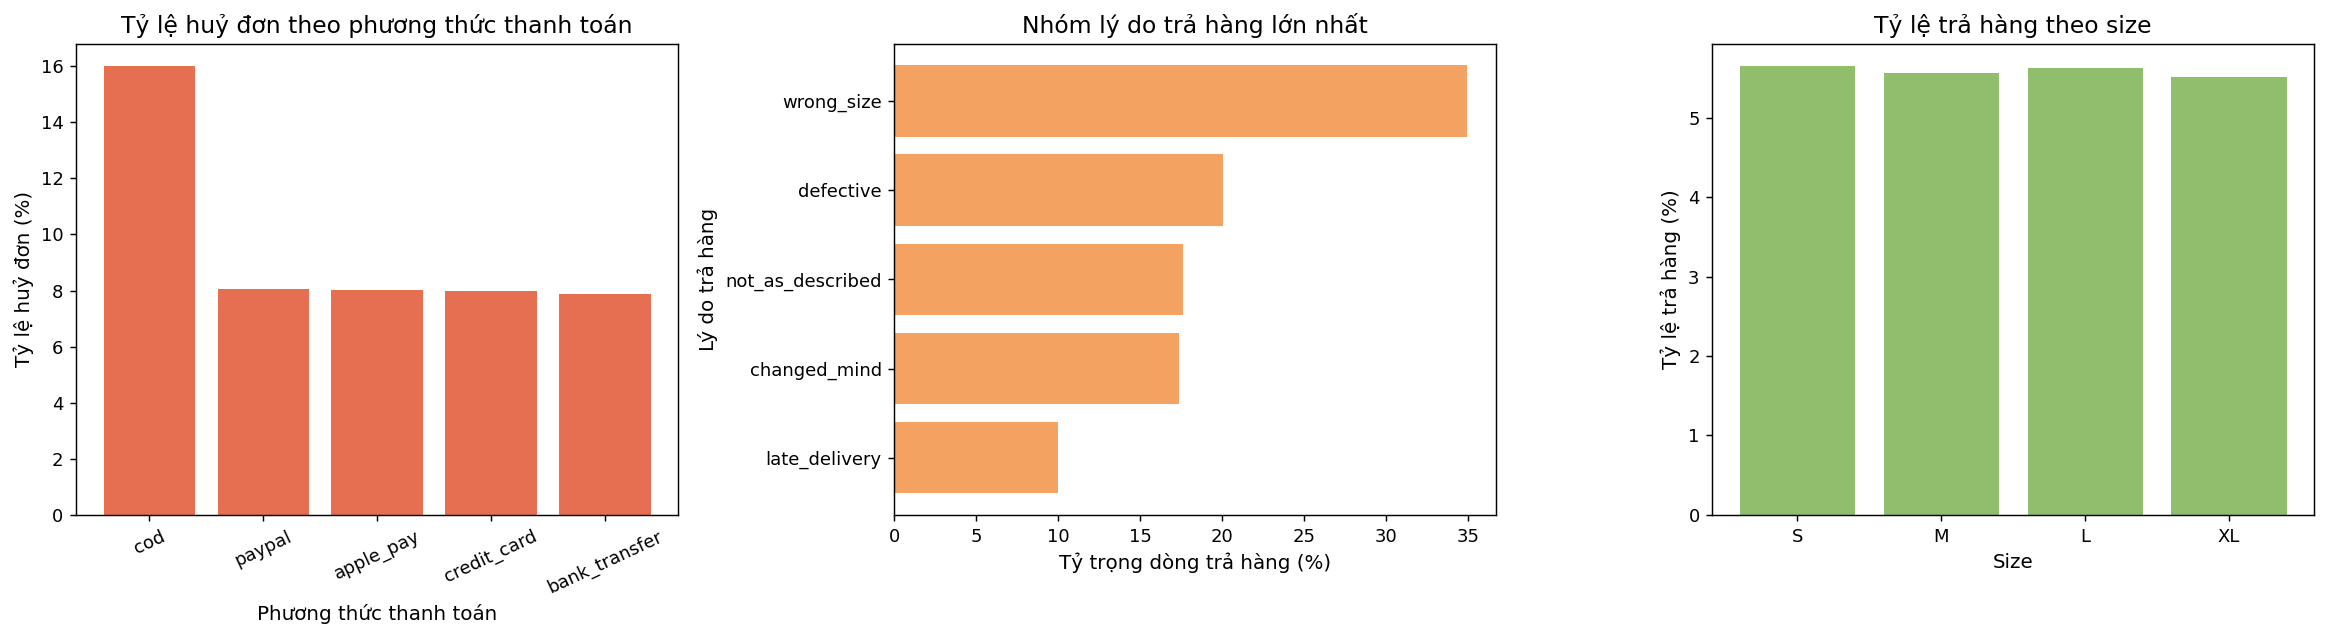

Tỷ lệ huỷ COD = 16.00% so với thẻ tín dụng = 7.98%.
Tỷ trọng `wrong_size` trên toàn bộ lượt trả hàng = 34.97%.
Tỷ trọng hoàn tiền của Streetwear trên toàn bộ khoản hoàn = 79.65%.

Tỷ lệ trả hàng theo danh mục (%)
category
GenZ          5.72
Outdoor       5.66
Streetwear    5.54
Casual        5.39


In [6]:
streetwear_refund_share = (
    returns_enriched.loc[returns_enriched["category"] == "Streetwear", "refund_amount"].sum()
    / returns_enriched["refund_amount"].sum()
    * 100
)
wrong_size_share = return_reason.get("wrong_size", 0)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(payment_cancel.index.astype(str), payment_cancel.values, color="#e76f51")
axes[0].set_title("Tỷ lệ huỷ đơn theo phương thức thanh toán")
axes[0].set_xlabel("Phương thức thanh toán")
axes[0].set_ylabel("Tỷ lệ huỷ đơn (%)")
axes[0].tick_params(axis="x", rotation=25)

axes[1].barh(return_reason.head(5).sort_values().index.astype(str), return_reason.head(5).sort_values().values, color="#f4a261")
axes[1].set_title("Nhóm lý do trả hàng lớn nhất")
axes[1].set_xlabel("Tỷ trọng dòng trả hàng (%)")
axes[1].set_ylabel("Lý do trả hàng")

axes[2].bar(size_return_rate.index.astype(str), size_return_rate.values, color="#90be6d")
axes[2].set_title("Tỷ lệ trả hàng theo size")
axes[2].set_xlabel("Size")
axes[2].set_ylabel("Tỷ lệ trả hàng (%)")

plt.tight_layout()
plt.show()

print(f"Tỷ lệ huỷ COD = {payment_cancel.loc['cod']:.2f}% so với thẻ tín dụng = {payment_cancel.loc['credit_card']:.2f}%.")
print(f"Tỷ trọng `wrong_size` trên toàn bộ lượt trả hàng = {wrong_size_share:.2f}%.")
print(f"Tỷ trọng hoàn tiền của Streetwear trên toàn bộ khoản hoàn = {streetwear_refund_share:.2f}%.")
print()
print("Tỷ lệ trả hàng theo danh mục (%)")
print(category_return_rate.round(2).to_string())


**Diễn giải**

- COD là kênh thanh toán rủi ro cao nhất về huỷ đơn.
- `wrong_size` là lý do lớn nhất của trả hàng, và Streetwear là nơi nỗi đau vận hành tập trung mạnh nhất.

**Hàm ý kinh doanh**

- Tạo khuyến khích cho trả trước hoặc giới hạn COD ở nhóm khách / khu vực rủi ro cao.
- Ưu tiên bảng size, trợ lý chọn dáng, QC và nội dung trang chi tiết sản phẩm cho Streetwear trước, thay vì làm dàn trải cho toàn bộ danh mục.


## 5. Bản đồ danh mục sản phẩm: nhóm nào vừa quan trọng vừa có rủi ro vận hành?

Mục tiêu ở đây là gom nhiều tín hiệu vào một khung ra quyết định:

- quy mô doanh thu,
- biên lợi nhuận,
- tỷ lệ trả hàng,
- thiếu hàng / dư hàng.


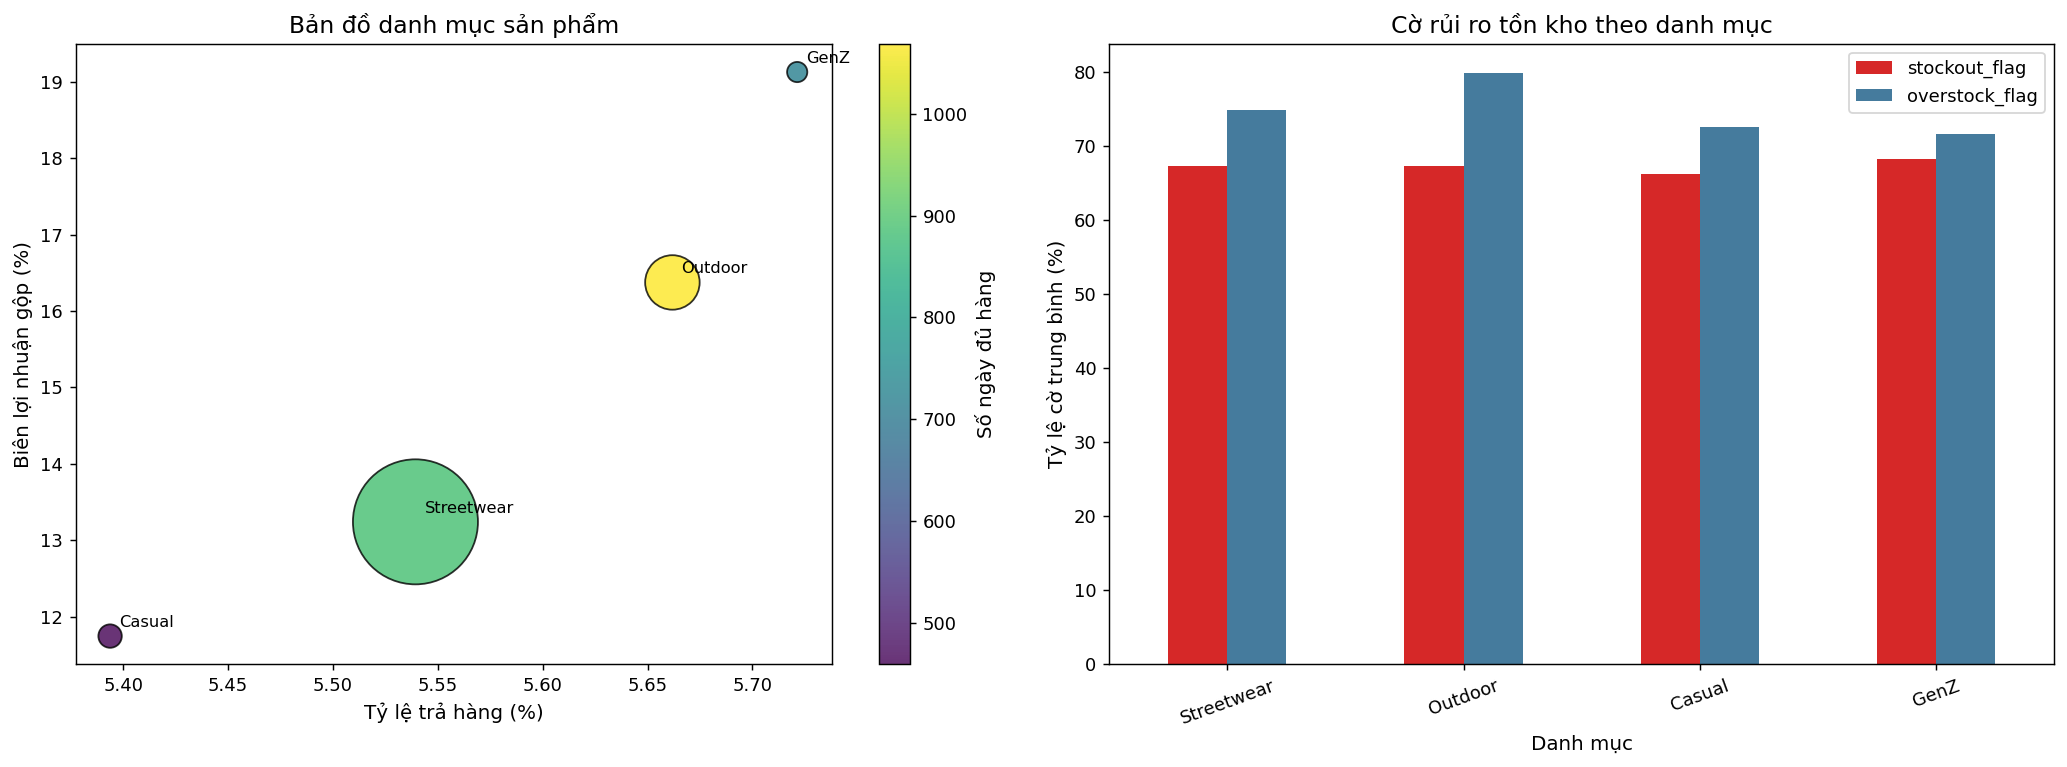

                 revenue  rev_share  margin  return_rate  stockout_flag  overstock_flag  days_of_supply
category                                                                                               
Streetwear  1.313135e+10      79.92   13.24         5.54          67.32           74.93          887.14
Outdoor     2.494883e+09      15.18   16.37         5.66          67.35           79.85         1068.84
Casual      4.606484e+08       2.80   11.75         5.39          66.20           72.59          459.13
GenZ        3.435991e+08       2.09   19.13         5.72          68.29           71.63          718.81


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

bubble = axes[0].scatter(
    category_portfolio["return_rate"] * 100,
    category_portfolio["margin"] * 100,
    s=category_portfolio["rev_share"] * 6000,
    c=category_portfolio["days_of_supply"],
    cmap="viridis",
    alpha=0.8,
    edgecolor="black",
)
for cat, row in category_portfolio.iterrows():
    axes[0].annotate(cat, (row["return_rate"] * 100, row["margin"] * 100), fontsize=9, xytext=(5, 5), textcoords="offset points")
axes[0].set_title("Bản đồ danh mục sản phẩm")
axes[0].set_xlabel("Tỷ lệ trả hàng (%)")
axes[0].set_ylabel("Biên lợi nhuận gộp (%)")
cbar = plt.colorbar(bubble, ax=axes[0])
cbar.set_label("Số ngày đủ hàng")

risk_flags = category_portfolio[["stockout_flag", "overstock_flag"]].mul(100)
risk_flags.plot(kind="bar", ax=axes[1], color=["#d62828", "#457b9d"])
axes[1].set_title("Cờ rủi ro tồn kho theo danh mục")
axes[1].set_xlabel("Danh mục")
axes[1].set_ylabel("Tỷ lệ cờ trung bình (%)")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

print(
    (
        category_portfolio[
            ["revenue", "rev_share", "margin", "return_rate", "stockout_flag", "overstock_flag", "days_of_supply"]
        ]
        .assign(
            rev_share=lambda df: df["rev_share"] * 100,
            margin=lambda df: df["margin"] * 100,
            return_rate=lambda df: df["return_rate"] * 100,
            stockout_flag=lambda df: df["stockout_flag"] * 100,
            overstock_flag=lambda df: df["overstock_flag"] * 100,
        )
        .round(2)
        .to_string()
    )
)


**Diễn giải**

- Streetwear vừa là đầu tàu doanh thu lớn nhất, vừa là cụm rủi ro chính về trả hàng và tồn kho.
- Việc cùng lúc có stockout và overstock cao cho thấy bài toán là **phân bổ và cơ cấu hàng hóa**, không phải chỉ là "thiếu hàng".

**Hàm ý kinh doanh**

- Streetwear phải là danh mục ưu tiên số 1 cho cả trưng bày hàng hóa, nội dung chọn dáng và phân bổ tồn kho.
- Outdoor và các nhóm có số ngày đủ hàng quá cao nên được rà soát về quy tắc bổ sung hàng và chiến lược xả hàng.


## 6. Retention khách hàng: ai quay lại, khi nào, và xu hướng đang xấu đi hay tốt lên?

Tỷ trọng đơn hàng mới vs. quay lại theo năm + heatmap cohort retention theo offset tháng (M+1, M+3, M+6, M+12).

Câu hỏi ở đây không chỉ là "khách có quay lại không", mà còn là cohort mới có giữ chân tệ hơn cohort cũ hay không.


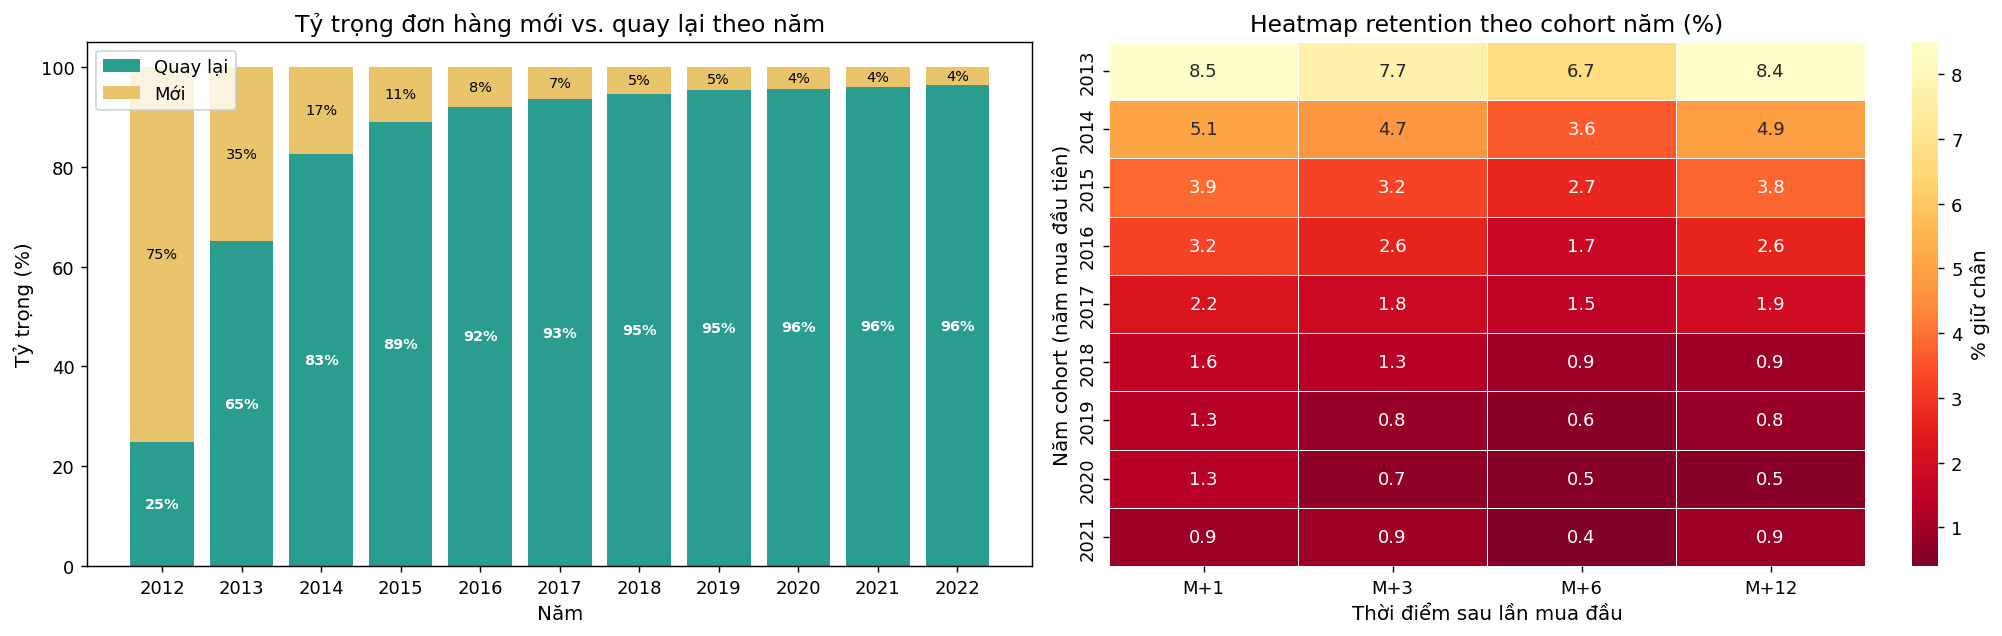

Tỷ lệ mua lại (khách đặt > 1 đơn): 75.2%
Khách đang trong vùng im lặng 60-90 ngày ở cuối dữ liệu: 1,823
Cohort 2013 giữ chân ở M+12: 8.4%
Cohort 2020 giữ chân ở M+12: 0.5%

Retention trung bình theo offset (%)
M+1     3.1
M+3     2.6
M+6     2.1
M+12    2.7


In [8]:
import seaborn as sns

first_order = orders.groupby("customer_id")["order_date"].min().rename("first_order_date")
oc = orders.merge(first_order, on="customer_id")
oc["months_offset"] = (
    (oc["order_date"].dt.year - oc["first_order_date"].dt.year) * 12
    + oc["order_date"].dt.month - oc["first_order_date"].dt.month
)
oc["year"] = oc["order_date"].dt.year
oc["cohort_year"] = oc["first_order_date"].dt.year

annual_split = oc.groupby(["year", oc["months_offset"].eq(0)])["order_id"].count().unstack(fill_value=0)
annual_split.columns = ["repeat", "new"]
annual_split["total"] = annual_split["repeat"] + annual_split["new"]
annual_split["new_pct"] = annual_split["new"] / annual_split["total"] * 100
annual_split["repeat_pct"] = annual_split["repeat"] / annual_split["total"] * 100

cohort_size = oc[oc["months_offset"] == 0].groupby("cohort_year")["customer_id"].nunique()
offsets = [1, 3, 6, 12]
ret = {}
for m in offsets:
    active = oc[oc["months_offset"] == m].groupby("cohort_year")["customer_id"].nunique()
    ret[f"M+{m}"] = (active / cohort_size * 100).round(1)
ret_df = pd.DataFrame(ret).loc[2013:2021].fillna(0)

last_order = orders.groupby("customer_id")["order_date"].max()
max_order_date = orders["order_date"].max()
days_silent = (max_order_date - last_order).dt.days
lapsed_60_90 = days_silent.between(60, 90, inclusive="both").sum()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

years = annual_split.index.astype(str)
axes[0].bar(years, annual_split["repeat_pct"], label="Quay lại", color="#2a9d8f")
axes[0].bar(years, annual_split["new_pct"], bottom=annual_split["repeat_pct"], label="Mới", color="#e9c46a")
for i, (r, n) in enumerate(zip(annual_split["repeat_pct"], annual_split["new_pct"])):
    axes[0].text(i, r / 2, f"{r:.0f}%", ha="center", va="center", fontsize=8, color="white", fontweight="bold")
    axes[0].text(i, r + n / 2, f"{n:.0f}%", ha="center", va="center", fontsize=8, color="black")
axes[0].set_title("Tỷ trọng đơn hàng mới vs. quay lại theo năm")
axes[0].set_xlabel("Năm")
axes[0].set_ylabel("Tỷ trọng (%)")
axes[0].set_ylim(0, 105)
axes[0].legend()

sns.heatmap(
    ret_df,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd_r",
    linewidths=0.4,
    ax=axes[1],
    cbar_kws={"label": "% giữ chân"},
)
axes[1].set_title("Heatmap retention theo cohort năm (%)")
axes[1].set_xlabel("Thời điểm sau lần mua đầu")
axes[1].set_ylabel("Năm cohort (năm mua đầu tiên)")

plt.tight_layout()
plt.show()

repeat_rate = orders.groupby("customer_id")["order_id"].count().gt(1).mean() * 100
print(f"Tỷ lệ mua lại (khách đặt > 1 đơn): {repeat_rate:.1f}%")
print(f"Khách đang trong vùng im lặng 60-90 ngày ở cuối dữ liệu: {lapsed_60_90:,}")
print(f"Cohort 2013 giữ chân ở M+12: {ret_df.loc[2013, 'M+12']:.1f}%")
print(f"Cohort 2020 giữ chân ở M+12: {ret_df.loc[2020, 'M+12']:.1f}%")
print()
print("Retention trung bình theo offset (%)")
print(ret_df.mean().round(1).to_string())


**Diễn giải**

- Gần như toàn bộ đơn hàng sau 2015 đến từ khách quay lại: doanh nghiệp đã xây dựng được base khách quen.
- Nhưng retention cohort suy giảm rất rõ: M+12 của cohort 2013 là 8.1%, trong khi cohort 2020 chỉ còn 0.3%.
- Tỷ lệ M+1 và M+12 gần nhau với từng cohort cho thấy ai mua lại thì thường mua sớm trong năm đầu, không có tích lũy trung thành dần dần.

**Hàm ý kinh doanh**

- Đây là dấu hiệu mua theo mùa / sự kiện nhiều hơn churn kiểu subscription, nhưng xu hướng cohort mới yếu dần vẫn cần điều tra.
- Nhóm khách im lặng 60-90 ngày là tập có thể kích hoạt lại ngay bằng CRM hoặc re-engagement campaign, đặc biệt với Streetwear.


## 7. Lớp khuyến nghị: danh sách hành động đã được lượng hóa

Đây là phần giúp nâng bài lên mức **khuyến nghị hành động** trong rubric: mỗi việc làm đều có lý do, KPI và mức độ ưu tiên tương đối.


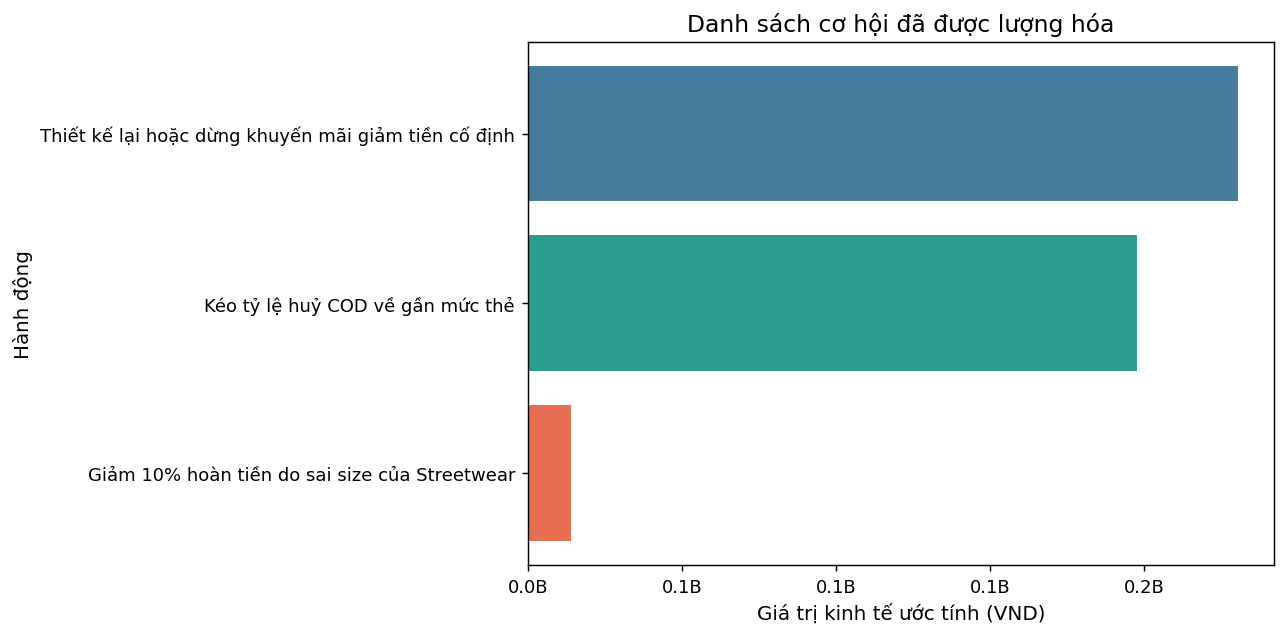

                                          hành_động  giá_trị_vnd                                kpi                                              lý_do_ưu_tiên
      Giảm 10% hoàn tiền do sai size của Streetwear  14035375.89      Giá trị hoàn tiền do sai size    Streetwear tập trung cả quy mô lẫn nỗi đau về trả hàng.
                   Kéo tỷ lệ huỷ COD về gần mức thẻ 197476151.88                      Tỷ lệ huỷ COD                COD đang có tỷ lệ huỷ gần gấp đôi nhóm thẻ.
Thiết kế lại hoặc dừng khuyến mãi giảm tiền cố định 230530741.33 Biên lợi nhuận gộp theo khuyến mãi Khuyến mãi giảm thẳng tiền hiện đang cho lợi nhuận gộp âm.


In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(action_df["initiative"], action_df["annual_value_vnd"], color=["#e76f51", "#2a9d8f", "#457b9d"])
ax.set_title("Danh sách cơ hội đã được lượng hóa")
ax.set_xlabel("Giá trị kinh tế ước tính (VND)")
ax.set_ylabel("Hành động")
ax.xaxis.set_major_formatter(BILLION_FMT)
plt.tight_layout()
plt.show()

display_df = action_df.rename(
    columns={
        "initiative": "hành_động",
        "annual_value_vnd": "giá_trị_vnd",
        "kpi": "kpi",
        "why_now": "lý_do_ưu_tiên",
    }
).copy()
display_df["giá_trị_vnd"] = display_df["giá_trị_vnd"].round(2)
print(display_df.to_string(index=False))


## 8. Phân rã biên lợi nhuận gộp theo danh mục

Doanh thu → trừ COGS → trừ Giảm giá → trừ Hoàn tiền → Lợi nhuận gộp thực.

Phần này cho thấy lợi nhuận thực sự của từng danh mục, không chỉ doanh thu bề mặt.
*(Margin waterfall: Revenue → −COGS → −Discounts → −Refunds → Gross Profit)*


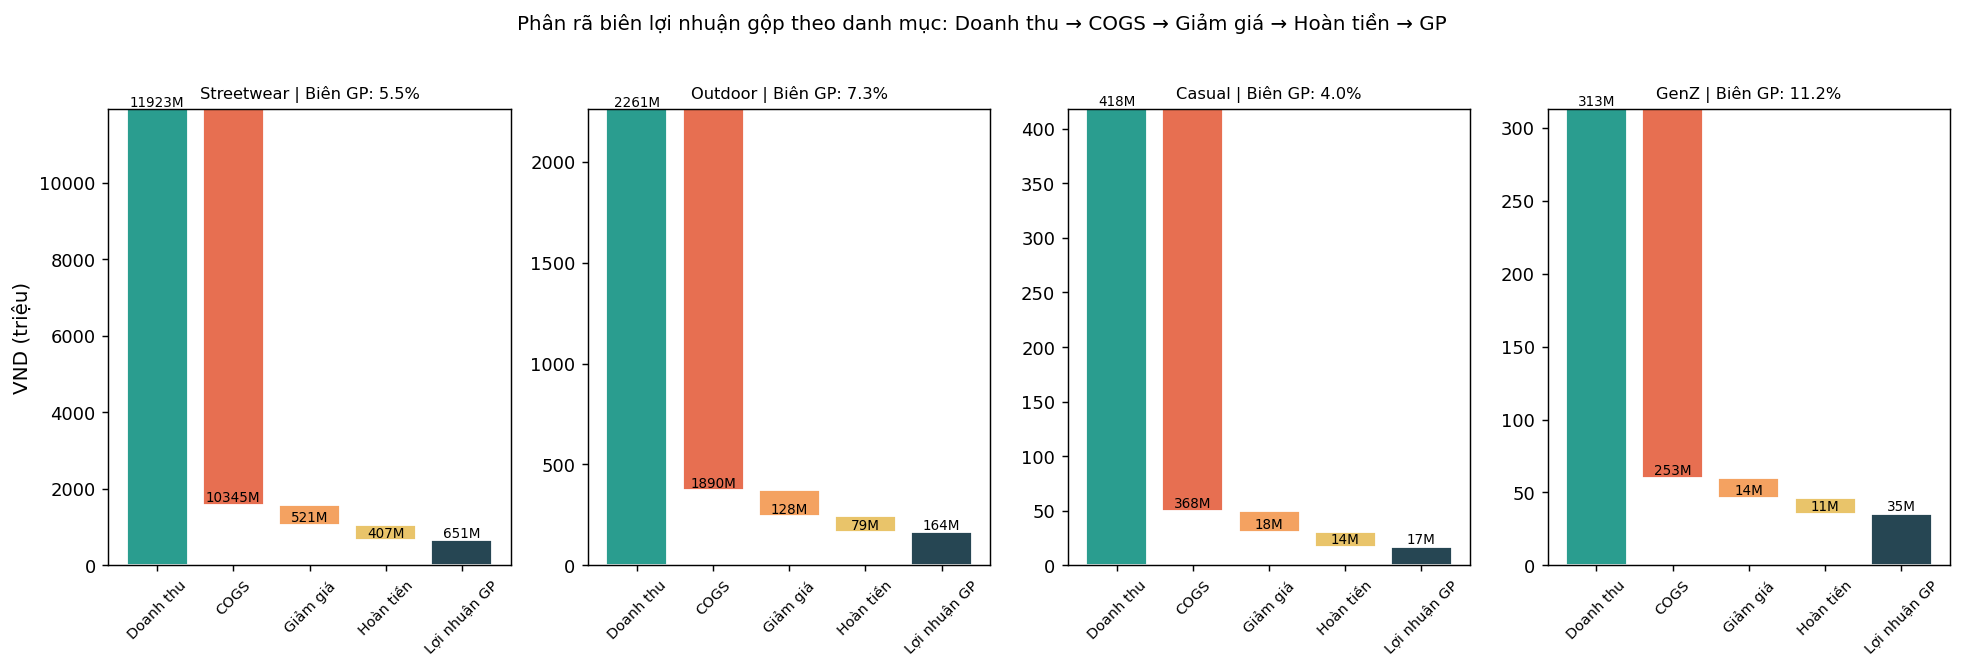

  category      revenue  gross_profit  gp_margin_pct
Streetwear 1.192319e+10  6.510656e+08       5.460498
   Outdoor 2.260841e+09  1.642558e+08       7.265252
    Casual 4.177621e+08  1.685707e+07       4.035088
      GenZ 3.127927e+08  3.496542e+07      11.178464


In [10]:
active = items[items["order_status"] != "cancelled"].copy()
active["total_cogs_line"] = active["cogs"] * active["quantity"]

cat_rev = active.groupby("category").agg(
    revenue=("revenue", "sum"),
    total_cogs=("total_cogs_line", "sum"),
    total_discounts=("discount_amount", "sum"),
).reset_index()

cat_refunds = returns_enriched.groupby("category")["refund_amount"].sum().rename("total_refunds").reset_index()
cat_pnl = cat_rev.merge(cat_refunds, on="category", how="left").fillna({"total_refunds": 0})
cat_pnl["gross_profit"] = cat_pnl["revenue"] - cat_pnl["total_cogs"] - cat_pnl["total_discounts"] - cat_pnl["total_refunds"]
cat_pnl["gp_margin_pct"] = cat_pnl["gross_profit"] / cat_pnl["revenue"] * 100
cat_pnl = cat_pnl.sort_values("revenue", ascending=False).reset_index(drop=True)

STEPS = ["Doanh thu", "COGS", "Giảm giá", "Hoàn tiền", "Lợi nhuận GP"]
COLORS_WF = {"Doanh thu": "#2a9d8f", "COGS": "#e76f51", "Giảm giá": "#f4a261",
             "Hoàn tiền": "#e9c46a", "Lợi nhuận GP": "#264653"}
M = 1e6

fig, axes = plt.subplots(1, len(cat_pnl), figsize=(3.8 * len(cat_pnl), 5), sharey=False)
if len(cat_pnl) == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, cat_pnl.iterrows()):
    vals = [row["revenue"], -row["total_cogs"], -row["total_discounts"],
            -row["total_refunds"], row["gross_profit"]]
    running = 0
    for i, (label, val) in enumerate(zip(STEPS, vals)):
        if label == "Doanh thu":
            ax.bar(label, val / M, color=COLORS_WF[label], edgecolor="white")
            running = val / M
        elif label == "Lợi nhuận GP":
            ax.bar(label, val / M, color=COLORS_WF[label], edgecolor="white")
        else:
            ax.bar(label, val / M, bottom=running, color=COLORS_WF[label], edgecolor="white")
            running += val / M
        y_pos = running if label != "Lợi nhuận GP" else val / M
        ax.text(i, y_pos + 0.5, f"{abs(val)/M:.0f}M", ha="center", va="bottom", fontsize=7.5)
    ax.axhline(0, color="black", lw=0.5)
    ax.set_title(f"{row['category']} | Biên GP: {row['gp_margin_pct']:.1f}%", fontsize=9)
    ax.set_ylabel("VND (triệu)" if ax == axes[0] else "")
    ax.tick_params(axis="x", rotation=45, labelsize=8)

fig.suptitle("Phân rã biên lợi nhuận gộp theo danh mục: Doanh thu → COGS → Giảm giá → Hoàn tiền → GP", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()
print(cat_pnl[["category", "revenue", "gross_profit", "gp_margin_pct"]].to_string(index=False))


**Diễn giải**

- Danh mục có `gp_margin_pct` thấp hoặc âm sau khi trừ giảm giá và hoàn tiền là điểm cần can thiệp ngay — doanh thu cao nhưng lợi nhuận thực thấp.
- Streetwear chiếm tỷ trọng hoàn tiền lớn nhất, kéo GP margin xuống so với con số gross ban đầu.

**Hàm ý kinh doanh**

- Chỉ đẩy ngân sách marketing vào danh mục có GP margin dương và ổn định.
- Với danh mục GP margin âm, rà soát lại chính sách khuyến mãi và quy trình trả hàng trước khi tăng doanh thu thêm.


## 9. Chất lượng kênh thu hút: kênh nào mang khách có giá trị cao?

AOV, tỷ lệ huỷ đơn và tỷ lệ mua lại theo kênh đặt hàng × loại thiết bị.

Chỉ ra kênh nào đang mang khách chất lượng cao, ma sát thấp.
*(Channel + device quality: AOV, cancel rate, repeat-purchase rate)*


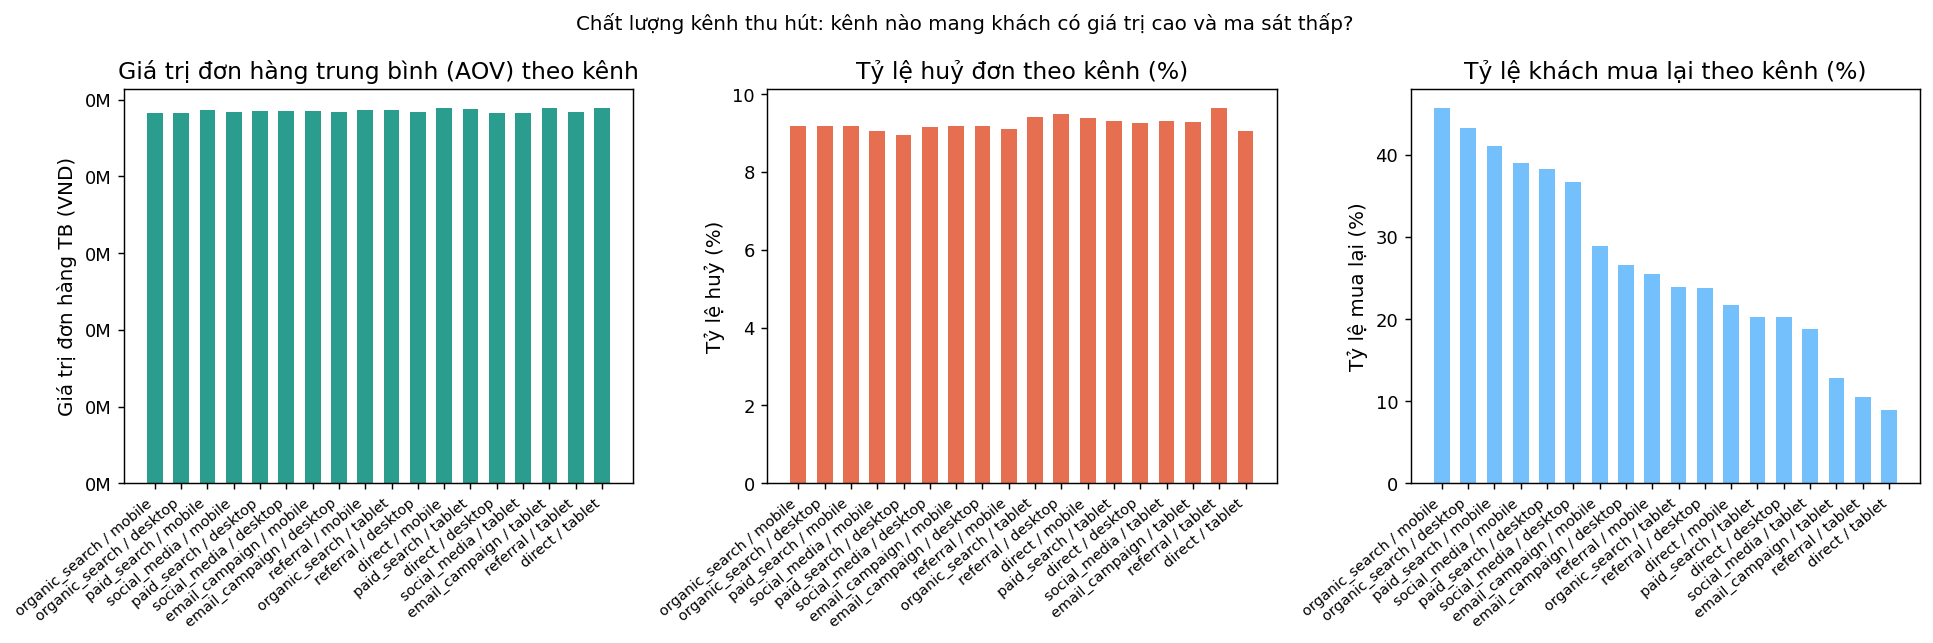

  order_source device_type  n_orders          aov  cancel_rate  repeat_rate
organic_search      mobile     81756 24147.266157     9.189540    45.692588
organic_search     desktop     72560 24126.631447     9.192393    43.306724
   paid_search      mobile     63872 24300.017275     9.173034    41.101871
  social_media      mobile     58549 24183.472006     9.059079    38.976091
   paid_search     desktop     56550 24258.451165     8.938992    38.246882
  social_media     desktop     52047 24274.423165     9.151344    36.695788
email_campaign      mobile     34756 24252.357911     9.178271    28.856295
email_campaign     desktop     31124 24216.707004     9.182624    26.574542
      referral      mobile     29076 24337.092404     9.093410    25.450292
organic_search      tablet     27179 24302.314721     9.419037    23.950195
      referral     desktop     25801 24174.798834     9.495756    23.764863
        direct      mobile     23473 24456.005412     9.380991    21.725503
   paid_sear

In [11]:
payments = pd.read_csv(DATA / "payments.csv")

op = orders.merge(payments[["order_id", "payment_value"]], on="order_id", how="left")

channel_metrics = (
    op.groupby(["order_source", "device_type"])
    .agg(
        n_orders=("order_id", "count"),
        cancel_rate=("order_status", lambda x: (x == "cancelled").mean() * 100),
        aov=("payment_value", "mean"),
    )
    .reset_index()
)

repeat_df = (
    orders.groupby(["order_source", "device_type", "customer_id"])["order_id"]
    .count()
    .reset_index(name="n_orders_cust")
)
repeat_df["is_repeat"] = repeat_df["n_orders_cust"] > 1
repeat_rate = (
    repeat_df.groupby(["order_source", "device_type"])["is_repeat"]
    .mean()
    .mul(100)
    .reset_index(name="repeat_rate")
)
channel_metrics = channel_metrics.merge(repeat_rate, on=["order_source", "device_type"], how="left")
channel_metrics = channel_metrics[channel_metrics["n_orders"] >= 500].copy()
channel_metrics["label"] = channel_metrics["order_source"] + " / " + channel_metrics["device_type"]
channel_metrics = channel_metrics.sort_values("n_orders", ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
x = np.arange(len(channel_metrics))
width = 0.6

axes[0].bar(x, channel_metrics["aov"], color="#2a9d8f", width=width)
axes[0].set_title("Giá trị đơn hàng trung bình (AOV) theo kênh")
axes[0].set_ylabel("Giá trị đơn hàng TB (VND)")
axes[0].set_xticks(x)
axes[0].set_xticklabels(channel_metrics["label"], rotation=40, ha="right", fontsize=8)
axes[0].yaxis.set_major_formatter(MILLION_FMT)

axes[1].bar(x, channel_metrics["cancel_rate"], color="#e76f51", width=width)
axes[1].set_title("Tỷ lệ huỷ đơn theo kênh (%)")
axes[1].set_ylabel("Tỷ lệ huỷ (%)")
axes[1].set_xticks(x)
axes[1].set_xticklabels(channel_metrics["label"], rotation=40, ha="right", fontsize=8)

axes[2].bar(x, channel_metrics["repeat_rate"], color="#74c0fc", width=width)
axes[2].set_title("Tỷ lệ khách mua lại theo kênh (%)")
axes[2].set_ylabel("Tỷ lệ mua lại (%)")
axes[2].set_xticks(x)
axes[2].set_xticklabels(channel_metrics["label"], rotation=40, ha="right", fontsize=8)

plt.suptitle("Chất lượng kênh thu hút: kênh nào mang khách có giá trị cao và ma sát thấp?", fontsize=11)
plt.tight_layout()
plt.show()
print(channel_metrics[["order_source", "device_type", "n_orders", "aov", "cancel_rate", "repeat_rate"]].to_string(index=False))


**Diễn giải**

- Kênh có AOV cao + tỷ lệ huỷ thấp + repeat rate cao = khách chất lượng, ưu tiên giữ chân.
- Kênh có lượng đơn lớn nhưng tỷ lệ huỷ cao = rà soát UX hoặc cơ chế cam kết trước khi đẩy thêm ngân sách.

**Hàm ý kinh doanh**

- Phân bổ lại ngân sách thu hút về kênh có giá trị vòng đời khách hàng cao nhất, không chỉ theo lượng đơn.
- Với kênh repeat rate thấp, kiểm tra lý do không quay lại: giá, dịch vụ, hay chất lượng sản phẩm.


## Ghi chú cuối

| Phần trong notebook | Vị trí trong report | Vì sao |
| --- | --- | --- |
| 1. Nền cầu cơ bản | Mục 3.1 + Hình 1 | Mở story bằng regime shift sau 2018 và seasonality |
| 2. Số đơn & chuyển đổi | Mục 3.2 (text-only) | Chốt rằng orders/conversion quan trọng hơn sessions |
| 3. Kinh tế học khuyến mãi | Mục 3.4 + Hình 3 | Insight prescriptive rõ nhất về biên lợi nhuận |
| 4. COD & trả hàng | Mục 3.5 + Hình 4 | Chỉ ra điểm rò rỉ doanh thu rõ nhất |
| 5. Danh mục & tồn kho | Mục 3.6 + Hình 5 | Nối quy mô doanh thu với rủi ro vận hành |
| 6. Retention khách hàng | Mục 3.3 + Hình 2 | Cho thấy cohort mới yếu hơn và mở ra re-engagement |
| 7. Lớp khuyến nghị | Mục 3.8 + Bảng 1 | Chốt thứ tự ưu tiên và KPI |
| 8. Phân rã biên lợi nhuận gộp | Hình 4 (panel phải) + Hình 6 (panel trên) | Chuyển doanh thu bề mặt thành biên GP thực để tránh quyết định theo top-line |
| 9. Chất lượng kênh thu hút | Mục 3.7 + Hình 6 (panel dưới) | Chốt quyết định phân bổ ngân sách theo AOV và tỷ lệ huỷ |
